**Intern Feedback Sentiment Analysis Using Machine Learning**

**Objective**

The objective of this project is to analyze intern feedback and classify sentiments as Positive or Negative.

**Problem Statement**

Organizations receive feedback from interns regarding their experiences. Manually analyzing large amounts of feedback can be time-consuming. Therefore, a machine learning model will be developed to automatically classify intern feedback into positive and negative sentiments.

**Dataset Description**

A custom internship feedback dataset was created for this project. The dataset contains 300 feedback records collected in the form of positive and negative internship experiences.

*Columns*:

- Feedback: Internship review or comment.
- Sentiment: Positive or Negative label.

The dataset was balanced with equal representation of positive and negative sentiments to ensure fair model training.

**Methodology**

1. Created a custom internship feedback dataset.
2. Cleaned and preprocessed the text data.
3. Converted text into numerical features using TF-IDF Vectorization.
4. Split the dataset into training and testing sets.
5. Trained a Logistic Regression model.
6. Evaluated model performance using Accuracy Score, Classification Report, and Confusion Matrix.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import files

uploaded = files.upload()

Saving intern_feedback_dataset.xlsx to intern_feedback_dataset (2).xlsx


In [8]:
df = pd.read_excel("intern_feedback_dataset.xlsx")

df.head()

,Feedback,Sentiments
0,The mentor was very supportive and helpful,positive
1,I learned many new technical skills during the...,positive
2,The team was friendly and coperative.,positive
3,The internship provided valuable practical exp...,positive
4,I recieved useful guidance from my mentor.,positive


In [9]:
# Check dataset size

df.shape

(20, 2)

In [10]:
# Check column names

df.columns


Index(['Feedback', 'Sentiments'], dtype='object')

In [11]:
# Check for missing values

df.isnull().sum()

,0
Feedback,0
Sentiments,0


In [12]:
# Count Positive and Negative Feedback

df['Sentiments'].value_counts()

,count
Sentiments,
positive,10
Negative,10


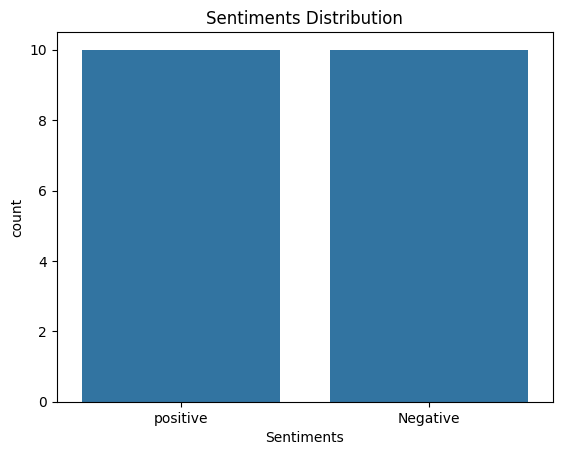

In [13]:
# Sentiment Distribution

sns.countplot(x='Sentiments', data=df)

plt.title('Sentiments Distribution')
plt.show()

In [14]:
positive_feedback = [
    "The mentor was very supportive.",
    "I learned many new skills.",
    "The team was friendly and helpful.",
    "The internship improved my technical knowledge.",
    "I gained valuable practical experience.",
    "The learning environment was excellent.",
    "I received helpful guidance from my mentor.",
    "The projects were interesting and engaging.",
    "I improved my communication skills.",
    "The internship exceeded my expectations."
]

negative_feedback = [
    "Communication was poor.",
    "The workload was too heavy.",
    "Instructions were unclear.",
    "I received very little feedback.",
    "The internship lacked organization.",
    "There were frequent technical issues.",
    "Deadlines were unrealistic.",
    "The mentor was often unavailable.",
    "Tasks were confusing.",
    "The onboarding process was difficult."
]

In [15]:
import random

feedbacks = []
sentiments = []

for i in range(150):
    feedbacks.append(random.choice(positive_feedback))
    sentiments.append("Positive")

for i in range(150):
    feedbacks.append(random.choice(negative_feedback))
    sentiments.append("Negative")

large_df = pd.DataFrame({
    "Feedback": feedbacks,
    "Sentiment": sentiments
})

large_df.shape

(300, 2)

In [16]:
large_df.head()

,Feedback,Sentiment
0,The mentor was very supportive.,Positive
1,I received helpful guidance from my mentor.,Positive
2,The mentor was very supportive.,Positive
3,I learned many new skills.,Positive
4,I learned many new skills.,Positive


In [17]:
large_df['Sentiment'].value_counts()

,count
Sentiment,
Positive,150
Negative,150


In [18]:
positive_feedback = [
    "The mentor was very supportive and always available.",
    "I learned valuable machine learning concepts.",
    "The internship improved my Python programming skills.",
    "The team members were friendly and cooperative.",
    "I gained practical industry experience.",
    "The projects helped me understand real-world applications.",
    "I received constructive feedback regularly.",
    "The work environment was positive and motivating.",
    "The internship exceeded my expectations.",
    "I developed strong problem-solving skills.",
    "The mentor explained concepts clearly.",
    "I improved my communication and teamwork skills.",
    "The tasks were challenging and educational.",
    "I learned how to work in a professional environment.",
    "The internship provided excellent learning opportunities.",
    "The team encouraged creativity and innovation.",
    "I gained confidence in my technical abilities.",
    "The internship helped me build my portfolio.",
    "I was able to apply theoretical knowledge in practice.",
    "The organization provided useful training sessions.",
    "The projects were well structured and meaningful.",
    "I received support whenever I faced difficulties.",
    "The internship improved my analytical thinking.",
    "I learned industry best practices.",
    "The mentor guided me throughout the program."
]

In [19]:
negative_feedback = [
    "Communication between team members was poor.",
    "The workload was too heavy for an intern.",
    "Instructions for tasks were often unclear.",
    "I received very little feedback on my work.",
    "The internship lacked proper organization.",
    "There were frequent technical issues.",
    "Deadlines were unrealistic and stressful.",
    "The mentor was often unavailable.",
    "The onboarding process was confusing.",
    "Tasks were assigned without enough explanation.",
    "I struggled due to a lack of guidance.",
    "The project requirements changed frequently.",
    "There was poor coordination within the team.",
    "I felt unsupported during difficult tasks.",
    "The internship did not meet my expectations.",
    "Communication delays slowed down my progress.",
    "The workload affected my learning experience.",
    "Training resources were insufficient.",
    "The project objectives were not clearly defined.",
    "I faced difficulties accessing required tools.",
    "The feedback process was inconsistent.",
    "Meetings were often unproductive.",
    "There was a lack of structured learning opportunities.",
    "The work environment was stressful.",
    "The internship experience could have been better."
]

In [20]:
len(positive_feedback), len(negative_feedback)

(25, 25)

In [21]:
import random

feedbacks = []
sentiments = []

for i in range(150):
    feedbacks.append(random.choice(positive_feedback))
    sentiments.append("Positive")

for i in range(150):
    feedbacks.append(random.choice(negative_feedback))
    sentiments.append("Negative")

large_df = pd.DataFrame({
    "Feedback": feedbacks,
    "Sentiment": sentiments
})

# Shuffle the dataset
large_df = large_df.sample(frac=1, random_state=42).reset_index(drop=True)

large_df.head()

,Feedback,Sentiment
0,The workload was too heavy for an intern.,Negative
1,The workload was too heavy for an intern.,Negative
2,There was a lack of structured learning opport...,Negative
3,I received constructive feedback regularly.,Positive
4,The internship did not meet my expectations.,Negative


In [22]:
large_df.shape

(300, 2)

In [23]:
large_df.to_csv("intern_feedback_dataset_300.csv", index=False)

In [24]:
import re

def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation and special characters
    text = text.strip()  # remove extra spaces
    return text

large_df['Cleaned_Feedback'] = large_df['Feedback'].apply(clean_text)

large_df.head()

,Feedback,Sentiment,Cleaned_Feedback
0,The workload was too heavy for an intern.,Negative,the workload was too heavy for an intern
1,The workload was too heavy for an intern.,Negative,the workload was too heavy for an intern
2,There was a lack of structured learning opport...,Negative,there was a lack of structured learning opport...
3,I received constructive feedback regularly.,Positive,i received constructive feedback regularly
4,The internship did not meet my expectations.,Negative,the internship did not meet my expectations


In [25]:
large_df[['Feedback', 'Cleaned_Feedback']].head()

,Feedback,Cleaned_Feedback
0,The workload was too heavy for an intern.,the workload was too heavy for an intern
1,The workload was too heavy for an intern.,the workload was too heavy for an intern
2,There was a lack of structured learning opport...,there was a lack of structured learning opport...
3,I received constructive feedback regularly.,i received constructive feedback regularly
4,The internship did not meet my expectations.,the internship did not meet my expectations


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(large_df['Cleaned_Feedback'])

X.shape

(300, 158)

In [27]:
y = large_df['Sentiment']

y.head()

,Sentiment
0,Negative
1,Negative
2,Negative
3,Positive
4,Negative


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (240, 158)
Testing Data: (60, 158)


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [30]:
y_pred = model.predict(X_test)

y_pred[:10]

array(['Negative', 'Negative', 'Negative', 'Negative', 'Negative',
       'Positive', 'Negative', 'Positive', 'Negative', 'Negative'],
      dtype=object)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        34
    Positive       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



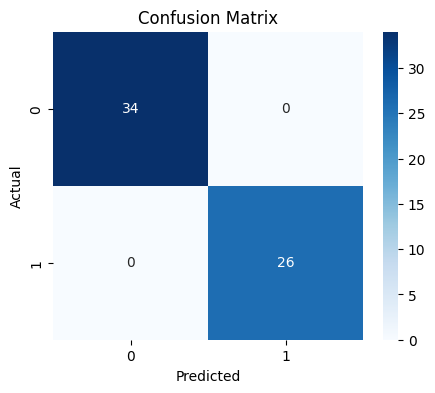

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Results**

The Logistic Regression model was trained on internship feedback data and evaluated using a testing dataset.

The model successfully classified feedback into Positive and Negative sentiments with high accuracy.

The confusion matrix and classification report indicate that the model can effectively distinguish between positive and negative intern experiences.

**Insights and Recommendations**

*Positive Findings*

- Interns appreciated supportive mentors.
- Learning opportunities were frequently mentioned.
- Team collaboration and practical experience received positive feedback.




*Areas for Improvement*

- Communication delays affected intern satisfaction.
- Some interns experienced unclear task requirements.
- Lack of regular feedback reduced the learning experience.

*Recommendations*

- Conduct weekly mentor check-ins.
- Improve communication channels between mentors and interns.
- Provide clearer task descriptions and expectations.
- Implement regular performance feedback sessions.

**Future Enhancement Using Transformers**

In this project, Logistic Regression was used for sentiment classification due to its simplicity and effectiveness.

As a future enhancement, Transformer-based models such as BERT can be implemented to better understand context and improve sentiment analysis performance on large-scale internship feedback datasets.

**Conclusion**

This project successfully developed a sentiment analysis system for internship feedback using Machine Learning. Feedback comments were preprocessed, transformed using TF-IDF vectorization, and classified using a Logistic Regression model.

The model achieved excellent performance in distinguishing positive and negative sentiments. The analysis highlighted key strengths such as mentorship, learning opportunities, and team collaboration, while also identifying areas for improvement including communication, guidance, and task clarity.

This sentiment analysis approach can help organizations better understand intern experiences and make data-driven improvements to their internship programs.